In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, RationalQuadratic

# Load Data
data = pd.read_csv('data/temp_daily_data.csv')

In [2]:
# Data Preprocessing
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y') # Ensure date is in datetime format

# Calculate Monthly Average Temperature
data['month'] = data['date'].dt.to_period('M') # Extract month for grouping
monthly_avg_temp = data.groupby('month')['temp'].mean().reset_index() # Calculate monthly average temperature
data['monthly_avg_temp'] = data['month'].map(monthly_avg_temp.set_index('month')['temp']) # Map monthly avg temp back to daily data

In [3]:
# --- Data preparation ---
X_train = np.arange(1000).reshape(-1, 1)  # first 1000 days as numeric sequence
y_train = data['temp'].iloc[:1000].values  # corresponding temperatures

In [4]:
# --- Custom kernel definition ---
kernel = (
    1.0 * RBF(length_scale=200.0)
    + 1.0 * ExpSineSquared(length_scale=50.0, periodicity=365.0)
    + 0.5 * RationalQuadratic(length_scale=80.0, alpha=1.0)
    + WhiteKernel(noise_level=0.5)
)

In [5]:
# --- Fit Gaussian Process Regressor ---
gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=3,
    random_state=0
)
gpr.fit(X_train, y_train)

c:\Users\Ethan\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,1**2 * RBF(le...ise_level=0.5)
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,3
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,0
,kernel__k1,1**2 * RBF(le...ngth_scale=80)
,kernel__k2,WhiteKernel(noise_level=0.5)
,kernel__k1__k1,1**2 * RBF(le...riodicity=365)


In [6]:
# --- Inspect model ---
print("Learned kernel:", gpr.kernel_)
print("Log Marginal Likelihood:", gpr.log_marginal_likelihood_value_)

Learned kernel: 1.02**2 * RBF(length_scale=75.4) + 0.00316**2 * ExpSineSquared(length_scale=28.1, periodicity=429) + 0.37**2 * RationalQuadratic(alpha=0.568, length_scale=1.21) + WhiteKernel(noise_level=0.0119)
Log Marginal Likelihood: -145.55501220296333


In [8]:
# --- In-sample prediction ---
y_pred, y_std = gpr.predict(X_train, return_std=True)

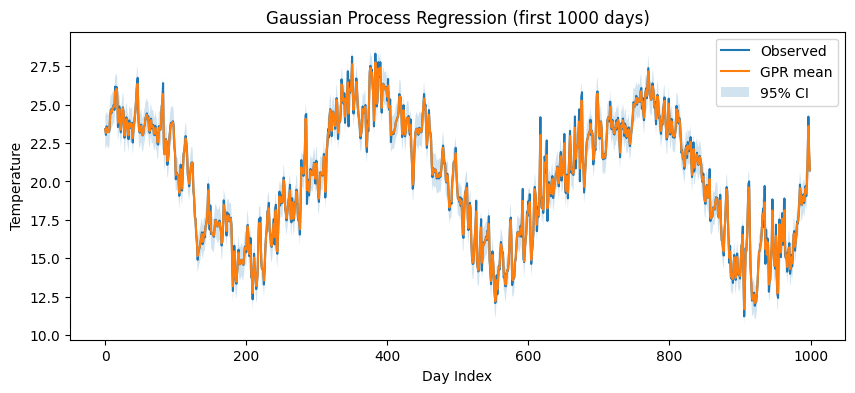

In [9]:
# --- Visualization ---
plt.figure(figsize=(10, 4))
plt.plot(X_train, y_train, label='Observed')
plt.plot(X_train, y_pred, label='GPR mean')
plt.fill_between(
    X_train.ravel(),
    y_pred - 1.96 * y_std,
    y_pred + 1.96 * y_std,
    alpha=0.2,
    label='95% CI'
)

plt.xlabel('Day Index')
plt.ylabel('Temperature')
plt.title('Gaussian Process Regression (first 1000 days)')
plt.legend()
plt.show()

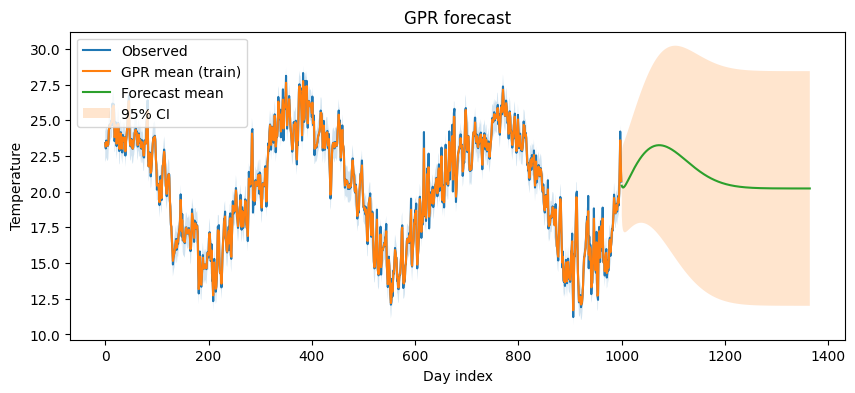

In [10]:
# 1) Future design matrix
H = 365  # forecast horizon in days
X_train = np.arange(1000).reshape(-1, 1)
X_future = np.arange(1000, 1000 + H).reshape(-1, 1)

# 2) Predictions
y_fit, s_fit = gpr.predict(X_train, return_std=True)
y_fore, s_fore = gpr.predict(X_future, return_std=True)

# 3) Plot
plt.figure(figsize=(10,4))
plt.plot(X_train.ravel(), data['temp'].iloc[:1000].values, label='Observed')
plt.plot(X_train.ravel(), y_fit, label='GPR mean (train)')
plt.fill_between(X_train.ravel(), y_fit - 1.96*s_fit, y_fit + 1.96*s_fit, alpha=0.2)

plt.plot(X_future.ravel(), y_fore, label='Forecast mean')
plt.fill_between(X_future.ravel(), y_fore - 1.96*s_fore, y_fore + 1.96*s_fore, alpha=0.2, label='95% CI')

plt.xlabel('Day index'); plt.ylabel('Temperature'); plt.title('GPR forecast')
plt.legend(); plt.show()
